# Post-processing gallery: one DC magnet through every verb

One physical problem -- a **saddle-coil dipole** built with the shipped
`radia.coil_builder.saddle_coil` API, with and without a soft-iron flux
return solved by **HDiv-VIM** (`radia.vim.MeshSoftIron` + `rad.Solve`) --
drives every post-processing verb of the `radia_mcp.gmsh` lane added in
the 2026-08 ParaView-parity rounds:

| section | verbs |
|---|---|
| figure controls | named camera presets, pinned colour range, labelled axes, annotations |
| comparison panels | `field_range` + `render_panels` (one camera, one zoom, ONE colour scale) |
| compound selection | `select` ("Find Data": fields x position, values carried into the extraction) |
| ray-cast volume + LIC | the real algorithms (`volume_raycast`, `lic`), coil STEP depth-composited |
| file-series time statistics | `time_series` (`argmax_time` as a picture, probed point histories) |

Everything is headless; every spatial figure is axis-equal (lab policy).
The gmsh verbs are called through their in-process Python API -- the MCP
tools wrap exactly these functions.

In [1]:
import json
import math
import os
import time

import numpy as np
import radia as rad
import radia.vim as vim
from ngsolve import Mesh, TaskManager
from netgen.occ import Box, OCCGeometry, Pnt

from radia.coil_builder import saddle_coil
from radia.gmsh_post_export import GmshPostExport

OUT = os.path.join(os.path.dirname(os.path.abspath("__file__")), "output")
os.makedirs(OUT, exist_ok=True)
mm = 1e-3

SADDLE = dict(radius=40 * mm, length=120 * mm, span_deg=70.0,
              bend_radius=6 * mm, width=10 * mm, height=8 * mm)
I_COIL = 5000.0
SEG = 10 * mm          # one segmentation everywhere: air and iron fields
                       # share the same coil discretization, so the
                       # comparison panels compare physics, not meshing

rad.UtiDelAll()
coils = []
for phi, sign in ((0.0, +1.0), (180.0, -1.0)):
    coils.append(saddle_coil(sign * I_COIL, phi_center_deg=phi, **SADDLE))
coil_objs = [o for c in coils for o in c.to_radia(arc_max_segment_length=SEG)]
coil_cnt = rad.ObjCnt(coil_objs)

steps = []
for k, c in enumerate(coils):
    p = os.path.join(OUT, f"saddle_{k}.step")
    c.write_step(p)
    steps.append(p)

B0_air = np.array(rad.Fld(coil_cnt, 'b', [0.0, 0.0, 0.0]))
print(f"air-core dipole: B(0) = {B0_air[0]:.5f} T "
      f"(By, Bz = {B0_air[1]:.2e}, {B0_air[2]:.2e})")

with TaskManager():
    slab = Mesh(OCCGeometry(Box(Pnt(-0.075, -0.085, -0.075),
                                Pnt(0.075, 0.085, 0.075))
                            ).GenerateMesh(maxh=0.014))
print(f"field box: {slab.ne} tets")

AIR_MSH = os.path.join(OUT, "gallery_air.msh")
with TaskManager():
    post = GmshPostExport(slab)
    post.add_vector_field("B", rad.RadiaField(coil_cnt, 'b'))
    post.write(AIR_MSH)

air-core dipole: B(0) = 0.07451 T (By, Bz = -2.33e-11, -2.60e-16)


field box: 4457 tets
GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\gallery_air.msh
  4457 elements, 1218 nodes, 1 fields
  Materials: default(4457)


## Geometry and the primary field

The mesh and the air-core field, interactively (webgui).

In [2]:
from ngsolve.webgui import Draw

Draw(slab, settings={"Objects": {"Wireframe": False}})

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {'Objects': {'Wireframe': Fals…

BaseWebGuiScene

In [3]:
B_air_cf = rad.RadiaField(coil_cnt, 'b')
Draw(B_air_cf, slab, name="B_magnitude", vectors={"grid_size": 40},
     autoscale=True, clipping={"y": -1, "dist": 0.0})

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

## Soft-iron flux return (HDiv-VIM)

Two field-parallel iron plates (mu_r = 1000) outside the coil.  The
demagnetization solve is the production HDiv-VIM path:
`radia.vim.MeshSoftIron` on NGSolve tet meshes inside `rad.Solve`
(charge-Gram H-matrix, mass-Riesz CG); the coils enter as analytic
Biot-Savart sources -- no air mesh anywhere.

In [4]:
t0 = time.perf_counter()
with TaskManager():
    plate_r = Mesh(OCCGeometry(Box(Pnt(0.055, -0.060, -0.045),
                                   Pnt(0.072, 0.060, 0.045))
                               ).GenerateMesh(maxh=0.022))
    plate_l = Mesh(OCCGeometry(Box(Pnt(-0.072, -0.060, -0.045),
                                   Pnt(-0.055, 0.060, 0.045))
                               ).GenerateMesh(maxh=0.022))
iron_r = vim.MeshSoftIron(plate_r, mu_r=1000.0)
iron_l = vim.MeshSoftIron(plate_l, mu_r=1000.0)
system = rad.ObjCnt([coil_cnt, iron_r, iron_l])
solve_info = rad.Solve(system, 1e-4, 1000, 2)
t_solve = time.perf_counter() - t0

B0_iron = np.array(rad.Fld(system, 'b', [0.0, 0.0, 0.0]))
enhancement = float(B0_iron[0] / B0_air[0])
print(f"plates: {plate_r.ne} + {plate_l.ne} tets; "
      f"outer iterations {solve_info['iterations']}, "
      f"converged {solve_info['converged']} ({t_solve:.0f} s)")
print(f"iron-assisted B(0) = {B0_iron[0]:.5f} T  "
      f"-> enhancement x{enhancement:.3f}")

IRON_MSH = os.path.join(OUT, "gallery_iron.msh")
with TaskManager():
    post = GmshPostExport(slab)
    post.add_vector_field("B", rad.RadiaField(system, 'b'))
    post.write(IRON_MSH)

plates: 152 + 152 tets; outer iterations 4, converged True (206 s)
iron-assisted B(0) = 0.08344 T  -> enhancement x1.120


GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\gallery_iron.msh
  4457 elements, 1218 nodes, 1 fields
  Materials: default(4457)


In [5]:
B_iron_cf = rad.RadiaField(system, 'b')
Draw(B_iron_cf, slab, name="B_magnitude", vectors={"grid_size": 40},
     autoscale=True, clipping={"y": -1, "dist": 0.0})

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.26…

BaseWebGuiScene

## Figure controls: named values instead of gmsh option strings

Camera presets point the named axis AT the camera (measured with a
marker rig -- guessing raw rotation angles is how a plane gets rendered
edge-on).  The colour range is PINNED, the axes carry units, the label
is drawn into the figure.

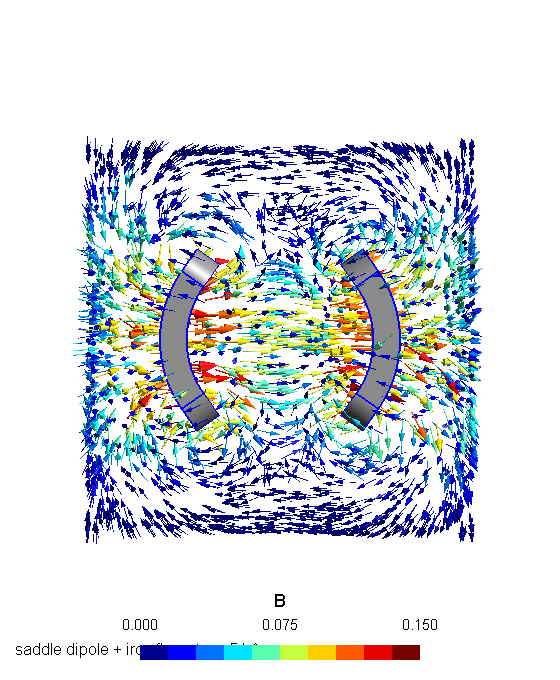

In [6]:
from IPython.display import Image as IImage
from radia_mcp.gmsh.render import render_png

fig1 = os.path.join(OUT, "fig_controls.png")
r = render_png(
    IRON_MSH, fig1, width=760, height=680, camera_preset="+y",
    merge_files=steps,
    color={"range": [0.0, 0.15], "style": "discrete", "intervals": 10,
           "format": "%.3f"},
    glyphs={"type": "arrow3d", "sampling": 2, "size_max": 42},
    annotations=[{"text": "saddle dipole + iron flux return, 5 kA",
                  "x": 15, "y": -25, "size": 16}],
    options={"General.SmallAxes": 0})
assert r["ok"] and not r["blank_check"]["looks_blank"], r
IImage(filename=fig1)

## Comparison panels: one camera, one zoom, one colour scale

`render_montage` pastes independent renders -- every panel auto-fits and
autoscales, so panels LOOK comparable while encoding different scales.
`render_panels` shares the camera, the zoom (a hidden bounding frame:
measured, gmsh refits every draw and ignores `General.Min*/Max*`) and
the colour range (`field_range` union).  Here that shared scale IS the
physics: the iron panel is visibly hotter on the SAME colourbar.

air  range: ['0.0008', '0.2168']
iron range: ['0.0008', '0.2326']
shared    : ['0.0008', '0.2326']


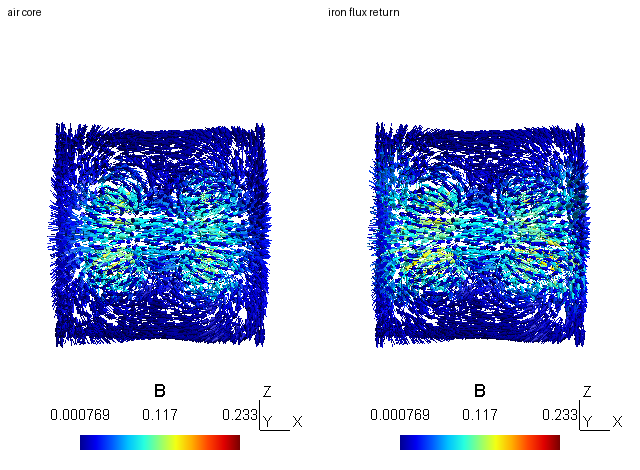

In [7]:
from radia_mcp.gmsh.post_process import field_range
from radia_mcp.gmsh.render import render_panels

rng = field_range([AIR_MSH, IRON_MSH], view="B")
print("air  range:", [f"{v:.4f}" for v in rng["per_file"][AIR_MSH]["range"]])
print("iron range:", [f"{v:.4f}" for v in rng["per_file"][IRON_MSH]["range"]])
print("shared    :", [f"{v:.4f}" for v in rng["range"]])

fig2 = os.path.join(OUT, "panels_air_iron.png")
p = render_panels(
    [{"path": AIR_MSH, "label": "air core"},
     {"path": IRON_MSH, "label": "iron flux return"}],
    fig2, view="B", camera_preset="+y", width=520, height=470)
assert p["ok"], p
IImage(filename=fig2)

## Compound selection ("Find Data")

`threshold` filters one view; `select` evaluates a boolean expression
per element over every view AND position, and `carry` rides the field
values into the extraction -- extracting the bare 1/0 mask would give a
flat blob whose colourbar reads "1".

selected 570 / 4457 elements (12.8%), carrying |B| in [0.0500, 0.1645] T


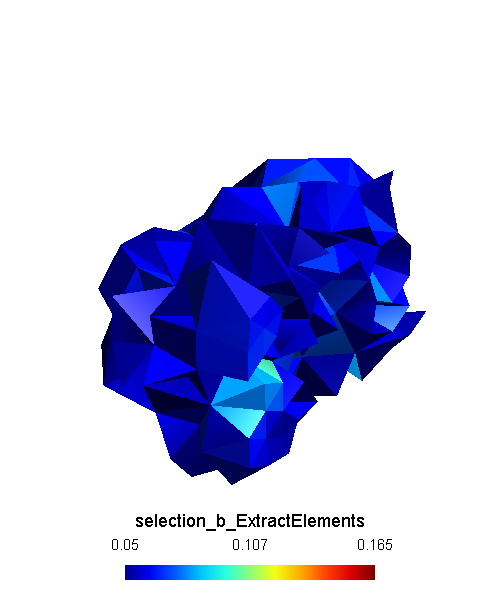

In [8]:
from radia_mcp.gmsh.post_process import select
from radia_mcp.gmsh.render import render_png as _rp

sel = select(IRON_MSH, "b > 0.05 and x > 0",
             out_file=os.path.join(OUT, "sel.msh"), carry="B")
print(f"selected {sel['n_selected']} / {sel['n_elements']} elements "
      f"({100 * sel['fraction']:.1f}%), carrying |B| in "
      f"[{sel['carried_range'][0]:.4f}, {sel['carried_range'][1]:.4f}] T")

fig3 = os.path.join(OUT, "selection.png")
r = _rp(os.path.join(OUT, "sel_extract.pos"), fig3, camera_preset="iso",
        width=700, height=600, options={"General.SmallAxes": 0})
assert r["ok"], r
IImage(filename=fig3)

## Ray-cast volume and LIC (the real algorithms)

gmsh has neither a ray-caster nor line integral convolution.  These two
run the genuine algorithms in numpy OVER gmsh-probed fields: rays march
front-to-back with physical occlusion (for a uniform medium the
returned minimum transmittance equals `(1-alpha)^n` exactly -- tested),
and white noise is advected along B so every pixel carries flow
direction.  The coil STEP is depth-composited INTO the ray march: the
field in front of the coil glows over it, the field behind is hidden.

raycast: 85184 probes, CAD covers 9% of pixels


lic: 340x340 px, 64 coil outline segments


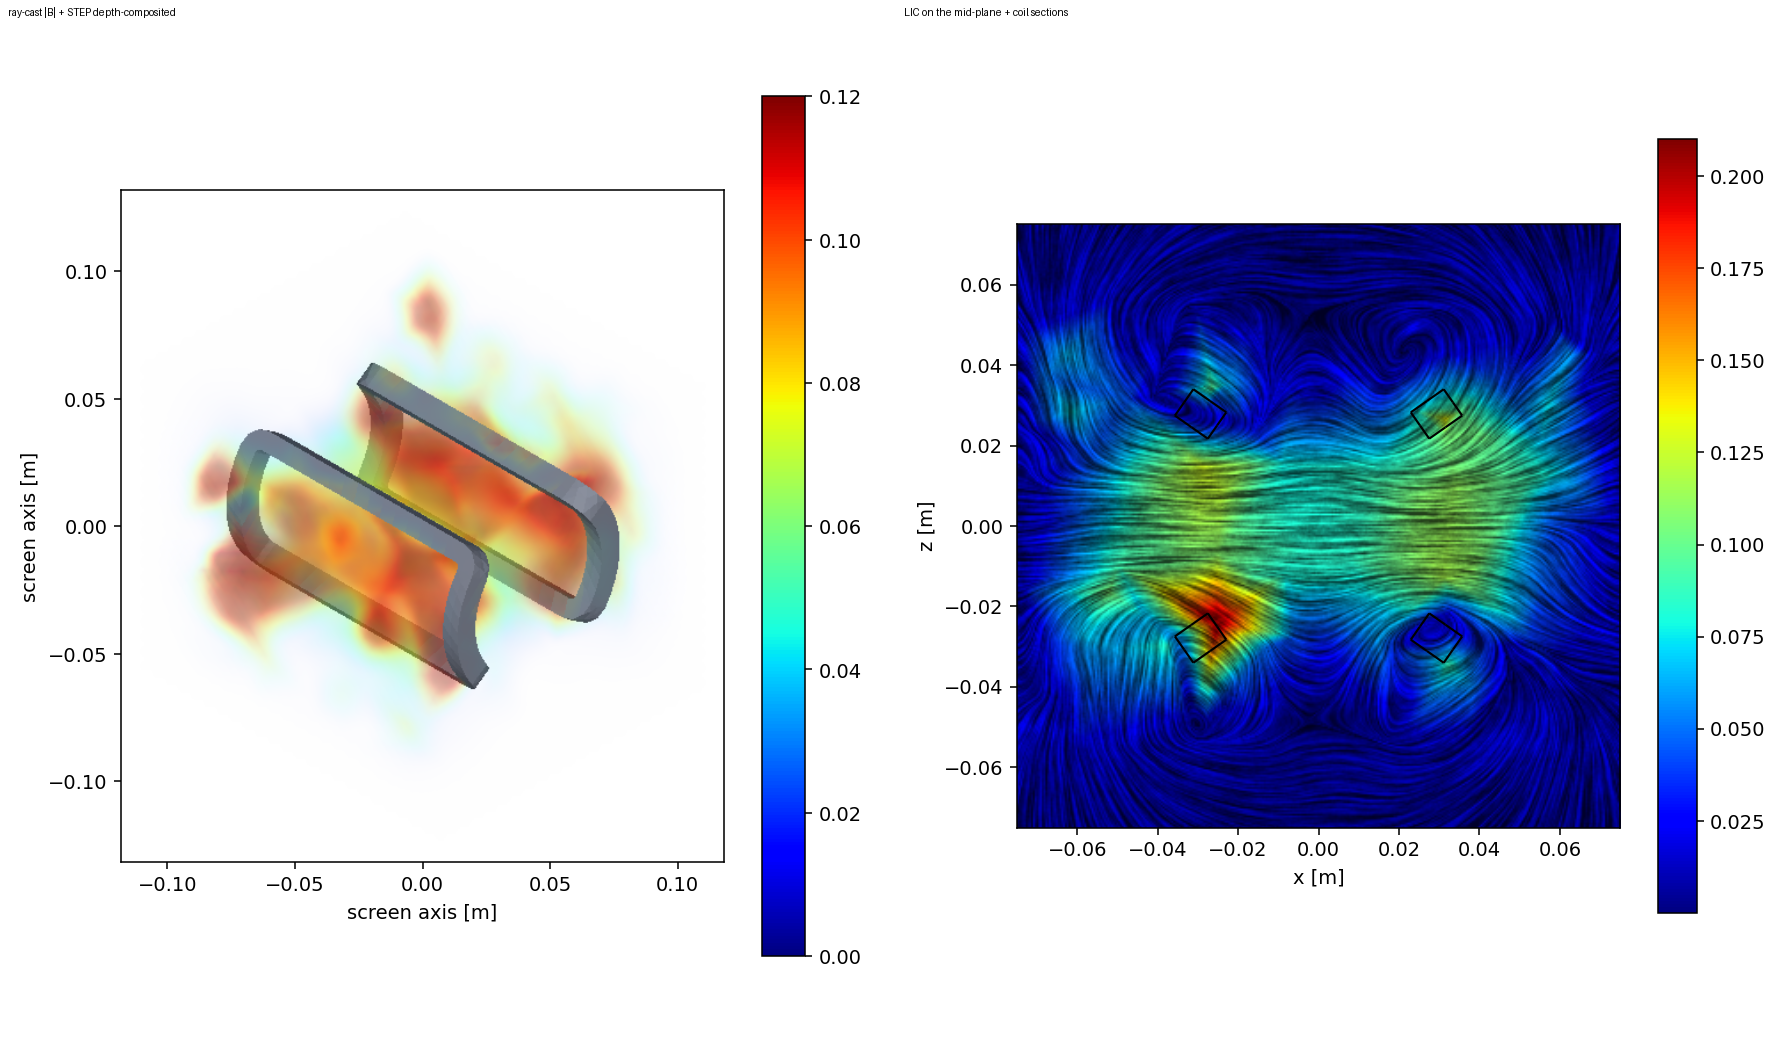

In [9]:
from radia_mcp.gmsh.raster import lic, volume_raycast
from radia_mcp.gmsh.render import render_montage

rc = volume_raycast(IRON_MSH, os.path.join(OUT, "raycast.png"), view="B",
                    grid=44, view_dir="iso", image_size=520,
                    alpha=0.15, alpha_power=2.5, value_range=[0.0, 0.12],
                    step_files=steps)
assert rc["ok"], rc
print(f"raycast: {rc['n_probes']} probes, "
      f"CAD covers {100 * rc['cad_covered_fraction']:.0f}% of pixels")

li = lic(IRON_MSH, os.path.join(OUT, "lic.png"), view="B",
         plane="xz", resolution=340, kernel=16, step_files=steps)
assert li["ok"], li
print(f"lic: {li['size'][0]}x{li['size'][1]} px, "
      f"{li['step_outline_segments']} coil outline segments")

fig4 = os.path.join(OUT, "raster_pair.png")
m = render_montage([rc["png"], li["png"]], fig4, cols=2,
                   labels=["ray-cast |B| + STEP depth-composited",
                           "LIC on the mid-plane + coil sections"])
IImage(filename=fig4)

## File-series time statistics

A transient run writes one mesh per step -- gmsh's own time steps live
inside a single view, so the lane treats an ordered FILE list as the
time axis.  Here the dipole pair sweeps along the beam axis; the
`argmax_time` view answers "where is the peak, and WHEN" as a picture,
and probed point histories give the classic plot-over-time.

GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\sweep_0.msh
  1386 elements, 520 nodes, 1 fields
  Materials: default(1386)
GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\sweep_1.msh
  1386 elements, 520 nodes, 1 fields
  Materials: default(1386)
GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\sweep_2.msh
  1386 elements, 520 nodes, 1 fields
  Materials: default(1386)


GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\sweep_3.msh
  1386 elements, 520 nodes, 1 fields
  Materials: default(1386)
GMSH export: S:\Radia\01_GitHub\docs\gmsh_post\output\sweep_4.msh
  1386 elements, 520 nodes, 1 fields
  Materials: default(1386)


stats views: ['B_min', 'B_max', 'B_mean', 'B_std', 'B_rms', 'B_ptp', 'B_argmax_time', 'B_argmin_time']
domain max over time: ['0.1963', '0.1969', '0.1421', '0.1835', '0.1838']


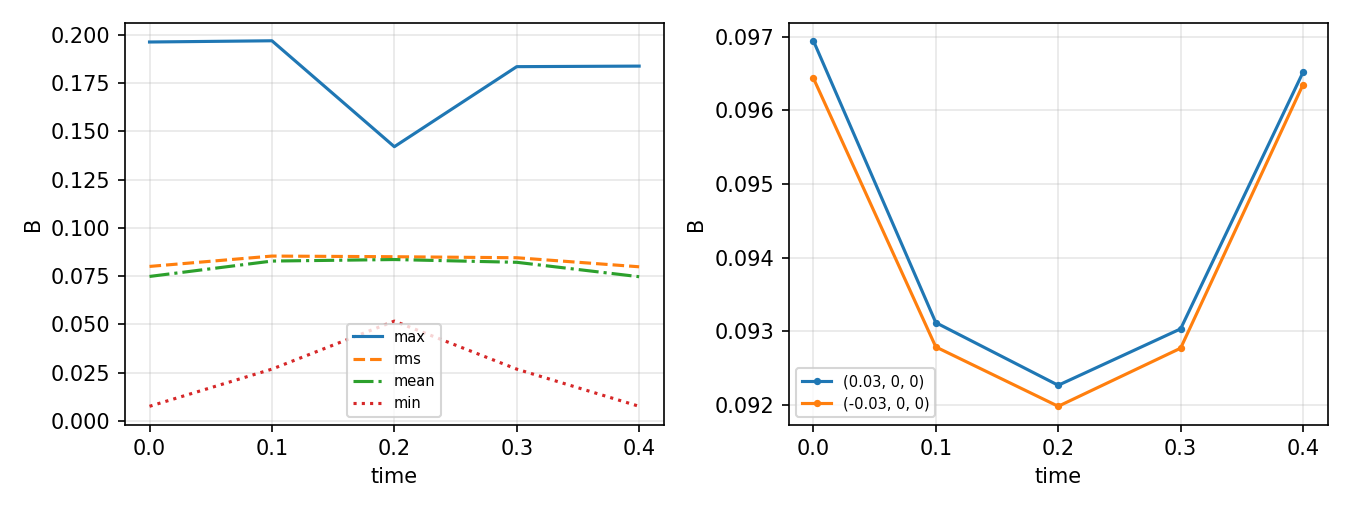

In [10]:
from radia_mcp.gmsh.post_process import time_series

with TaskManager():
    thin = Mesh(OCCGeometry(Box(Pnt(-0.05, -0.05, -0.003),
                                Pnt(0.05, 0.05, 0.003))
                            ).GenerateMesh(maxh=0.007))
series = []
for k, y0 in enumerate(np.linspace(-0.03, 0.03, 5)):
    rad.UtiDelAll()
    objs = []
    for phi, sign in ((0.0, +1.0), (180.0, -1.0)):
        c = saddle_coil(sign * I_COIL, phi_center_deg=phi, **SADDLE)
        objs.extend(o for o in c.to_radia(arc_max_segment_length=SEG))
    moving = rad.ObjCnt(objs)
    rad.TrfOrnt(moving, rad.TrfTrsl([0.0, float(y0), 0.0]))
    f = os.path.join(OUT, f"sweep_{k}.msh")
    with TaskManager():
        post = GmshPostExport(thin)
        post.add_vector_field("B", rad.RadiaField(moving, 'b'))
        post.write(f)
    series.append(f)
rad.UtiDelAll()

ts = time_series(series, view="B", times=[k * 0.1 for k in range(5)],
                 out_file=os.path.join(OUT, "sweep_stats.msh"),
                 points=[[0.03, 0.0, 0.0], [-0.03, 0.0, 0.0]],
                 plot_png=os.path.join(OUT, "sweep_history.png"))
assert ts["ok"], ts
print("stats views:", ts["stats_written"])
print("domain max over time:",
      [f"{v:.4f}" for v in ts["aggregate"]["max"]])
IImage(filename=ts["plot"]["png"])

## Recorded results

The numbers a reader should be able to reproduce are embedded below. Checked
numerical evidence lives under `validation_test/gmsh_post/`; no notebook hash
ledger is maintained.


In [11]:
import platform
from datetime import datetime, timezone

import ngsolve

summary = {
    "generated_at_utc": datetime.now(timezone.utc)
                        .strftime("%Y-%m-%dT%H:%M:%SZ"),
    "radia_version": rad.__version__ if hasattr(rad, "__version__")
                     else "unknown",
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "versions": {"ngsolve": ngsolve.__version__},
    "saddle": {k: (v if not isinstance(v, float) else round(v, 6))
               for k, v in SADDLE.items()},
    "current_A": I_COIL,
    "B0_air_T": float(B0_air[0]),
    "B0_iron_T": float(B0_iron[0]),
    "iron_enhancement": enhancement,
    "solve_outer_iterations": int(solve_info["iterations"]),
    "shared_colour_range_T": [float(v) for v in rng["range"]],
    "selection_fraction": float(sel["fraction"]),
    "raycast_cad_covered_fraction": float(rc["cad_covered_fraction"]),
    "lic_outline_segments": int(li["step_outline_segments"]),
    "sweep_domain_max_T": [float(v) for v in ts["aggregate"]["max"]],
}
print(json.dumps(summary, indent=1)[:800])

{
 "generated_at_utc": "2026-08-09T06:14:53Z",
 "radia_version": "4.95.50",
 "python_version": "3.12.10",
 "platform": "Windows-2022Server-10.0.20348-SP0",
 "versions": {
  "ngsolve": "6.2.2604"
 },
 "saddle": {
  "radius": 0.04,
  "length": 0.12,
  "span_deg": 70.0,
  "bend_radius": 0.006,
  "width": 0.01,
  "height": 0.008
 },
 "current_A": 5000.0,
 "B0_air_T": 0.07451058060140127,
 "B0_iron_T": 0.08343886022194553,
 "iron_enhancement": 1.1198256616507476,
 "solve_outer_iterations": 4,
 "shared_colour_range_T": [
  0.0007692458094549971,
  0.2325602659738485
 ],
 "selection_fraction": 0.12788871438187122,
 "raycast_cad_covered_fraction": 0.09162348877374785,
 "lic_outline_segments": 64,
 "sweep_domain_max_T": [
  0.1963070681725796,
  0.19694225320023237,
  0.14205712471216486,
  0.18353
